# Lab 8: Navier-Stokes equations

We consider the stationary Navier-Stokes problem defined in the unit square domain $\Omega := {[0,1]}^2$
$$
\begin{cases}
  ({\boldsymbol{u}}\cdot\boldsymbol{\nabla})\ \boldsymbol{u}
  -\dfrac{1}{\text{Re}}\boldsymbol{\Delta} \boldsymbol{u} + \boldsymbol{\nabla} p = 0, 
  \qquad&\text{in }\Omega, \\
  \boldsymbol{\nabla} \cdot \boldsymbol{u} = 0, 
  \qquad &\text{in }\Omega, \\
  \boldsymbol{u} = 1\boldsymbol{i} + 0\boldsymbol{j}, \qquad&\text{on }\Gamma^{\text{up}} = \{ 0 \le x \le 1, \, y=1 \}, \\
  \boldsymbol{u} = \boldsymbol{0}, \qquad&\text{on }\partial\Omega \backslash \Gamma^{\text{up}}.
\end{cases}
$$

## Numerical approximation with FEniCS

In [0]:
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *
from fenics import *

### Taylor-Hood discretization

Using the stable pair of spaces $\mathbb{P}^2/\mathbb{P}^1$ solve the problem using the **fixed-point iteration method**. Consider a stopping criterion based on the relative increment
$$
\frac{||\boldsymbol{u}_k-\boldsymbol{u}_{k-1}||_{H^1}}{||\boldsymbol{u}_{k-1}||_{H^1}}
+\frac{||\boldsymbol{p}_k-\boldsymbol{p}_{k-1}||_{L^2}}{||\boldsymbol{p}_{k-1}||_{L^2}}
\le 10^{-6}.
$$

*   Try to solve the problem with different values of Reynolds number ($\text{Re}=3,30,300,3000$). 
*   Assess the convergence performance of the iterative method.

In [0]:
# 1. mesh generation
nx, ny = 20, 20
mesh = UnitSquareMesh(nx, ny, 'crossed')

# 2. finite element space
degree = 1
V = VectorElement('CG', mesh.ufl_cell(), degree+1)
Q = FiniteElement('CG', mesh.ufl_cell(), degree)

X = FunctionSpace(mesh, MixedElement([V, Q]))

u_boundary = Expression((
        'near(x[1], 1) ? 1.0 : 0.0',
        '0'
    ), degree=0)

def boundary(x, on_boundary):
  return on_boundary

def origin(x, on_boundary):
  return near(x[0], 0) and near(x[1], 0)

bc = [
    DirichletBC(X.sub(0), u_boundary, boundary),
    DirichletBC(X.sub(1), Constant(0), origin, 'pointwise')
]

In [0]:
# 3. problem definition

def solve_linear(X, advection, Re, f, bc):
  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)

  a = (inner(grad(u), grad(v)) / Re - p * div(v) + div(u) * q) * dx
  L = dot(f, v) * dx
  if advection:
    a += dot(grad(u) * advection, v) * dx
  
  x = Function(X)
  solve(a == L, x, bc)
  
  return x.split()

In [14]:
# 4. solution
Re = Constant(300)
f = Constant((0, 0))

uh, ph = solve_linear(X, None, Re, f, bc)

niter = 100
tolerance = 1e-6
for i in range(niter):
  uh_old, ph_old = uh, ph
  uh, ph = solve_linear(X, uh_old, Re, f, bc)
  
  error = (errornorm(uh, uh_old, 'H1') / norm(uh_old, 'H1') +
           errornorm(ph, ph_old, 'L2') / norm(ph_old, 'L2'))
  print('step {}: {:.3e}'.format(i, error))
  if error < tolerance:
    break

uh.rename('velocity', 'velocity')
ph.rename('pressure', 'pressure')

File('velocity.pvd') << uh
File('pressure.pvd') << ph

step 0: 2.757e+00
step 1: 4.595e-01
step 2: 1.222e-01
step 3: 2.672e-02
step 4: 6.152e-03
step 5: 1.756e-03
step 6: 7.921e-04
step 7: 4.148e-04
step 8: 1.611e-04
step 9: 6.596e-05
step 10: 3.307e-05
step 11: 1.526e-05
step 12: 7.071e-06
step 13: 3.392e-06
step 14: 1.598e-06
step 15: 7.476e-07


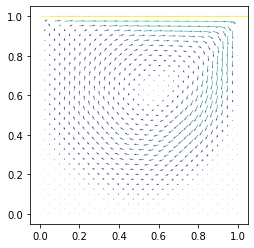

In [17]:
plot(uh)

### SUPG stabilized FEM

We introduce the SUPG stabilization for the solution of the
linearized problem. Use the following stabilization parameter
$$
\delta_K = \frac{h_K}{2 ||{\boldsymbol{u}}||} \xi(\mathbb{P}e_K),
$$
 where the local Péclet number is defined as
$$
\mathcal{Pe}_K := \frac{||{\boldsymbol{u}}||h_K}{2} \text{Re},
$$
and $\xi$ is the *upwind* function
$$
      \xi(\theta) = \min{(1,\theta)}.
$$
Compare the solutions of the previous point with the solutions obtained with the SUPG stabilization.

In [0]:
# 3. problem definition
def solve_linear(X, advection, Re, f, bc):
  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)
  
  a = (inner(grad(u), grad(v)) / Re - p * div(v) + div(u) * q) * dx
  L = dot(f, v) * dx
  if advection:
    a += dot(grad(u) * advection, v) * dx

    A = lambda u, p: -div(grad(u)) / Re + (grad(u) * advection) + div(advection) * u / 2 + grad(p)
    A_SS = lambda u, p: (grad(u) * advection) + div(advection) * u / 2 + grad(p)
  
    h = CellDiameter(X.mesh())
    anorm = sqrt(dot(advection, advection))
    tau_K = 0.5 * h / conditional(anorm * h * Re > 2, anorm, 2 / h / Re)
  
    a += tau_K * (dot(A(u, p), A_SS(v, q)) + div(u) * div(v)) * dx
    L += tau_K * (dot(f, A_SS(v, q))) * dx
  
  x = Function(X)
  solve(a == L, x, bc)
  
  return x.split()

In [12]:
# 4. solution
Re = Constant(3000)
f = Constant((0, 0))

uh, ph = solve_linear(X, Constant((0, 0)), Re, f, bc)

niter = 40
tolerance = 1e-6
for i in range(niter):
  uh_old, ph_old = uh, ph
  uh, ph = solve_linear(X, uh_old, Re, f, bc)
  
  error = (errornorm(uh, uh_old, 'H1') / norm(uh_old, 'H1') +
           errornorm(ph, ph_old, 'L2') / norm(ph_old, 'L2'))
  print('step {}: {:.3e}'.format(i, error))
  if error < tolerance:
    break

uh.rename('velocity', 'velocity')
ph.rename('pressure', 'pressure')

File('velocity.pvd') << uh
File('pressure.pvd') << ph

step 0: 9.796e+00
step 1: 9.587e-01
step 2: 3.622e-01
step 3: 1.657e-01
step 4: 1.967e-01
step 5: 4.730e-02
step 6: 2.252e-02
step 7: 1.113e-02
step 8: 4.262e-03
step 9: 4.260e-03
step 10: 2.078e-03
step 11: 1.754e-03
step 12: 9.583e-04
step 13: 5.455e-04
step 14: 4.081e-04
step 15: 2.525e-04
step 16: 1.263e-04
step 17: 8.297e-05
step 18: 5.296e-05
step 19: 3.050e-05
step 20: 1.937e-05
step 21: 1.109e-05
step 22: 6.350e-06
step 23: 4.349e-06
step 24: 2.601e-06
step 25: 1.395e-06
step 26: 8.891e-07


#### **Exercise**: Repeat the exercise using the pair of spaces $\mathbb{P}^1/\mathbb{P}^1$.